In [143]:
# Data
import pandas as pd
import geopandas as gpd
import numpy as np
import dill

# Package management
import os
import sys
import importlib

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
import seaborn as sns
sns.set_style('ticks') # For x and y axis ticks
sns.set_context("paper")

# Gaussian Processes
import gpflow
gpflow.config.set_default_float(np.float64)
gpflow.config.set_default_summary_fmt("notebook")
f64 = gpflow.utilities.to_default_float # convert to float64 for tfp to play nicely with gpflow
dtype = gpflow.config.default_float()

# Tensorflow
import tensorflow as tf
import tensorflow_probability as tfp

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# For Linear Extrapolation Baseline Model
from sklearn.linear_model import LinearRegression

# Progress Bars
from tqdm.notebook import tqdm

# Defining multiple variable types
from typing import Union
Numeric = Union[float, int, np.ndarray, pd.Series, pd.DataFrame]

# Add the parent directory to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))

import ev_forecaster.data_processing.data_processing
import ev_forecaster.models.model
import ev_forecaster.model_utils.mean_function
import ev_forecaster.model_utils.transforms 
import ev_forecaster.validation.historical_training_and_evaluation
import ev_forecaster.models.baselines

importlib.reload(ev_forecaster.data_processing.data_processing)
importlib.reload(ev_forecaster.models.model)
importlib.reload(ev_forecaster.model_utils.mean_function)
importlib.reload(ev_forecaster.model_utils.transforms)
importlib.reload(ev_forecaster.validation.historical_training_and_evaluation)
importlib.reload(ev_forecaster.models.baselines)

from ev_forecaster.data_processing.data_processing import LSOAVehicleRegistrationDataProcessor, LADVehicleRegistrationDataProcessor
from ev_forecaster.models.model import GPForecastingModel, JointGPForecaster
from ev_forecaster.model_utils.mean_function import CustomMeanFunction, Spline
from ev_forecaster.model_utils.transforms import probit, invprobit
from ev_forecaster.validation.historical_training_and_evaluation import GPForecastValidator
from ev_forecaster.models.baselines import BaselineForecaster, BaselineEvaluator, BaselineNMAEComparator, ScaledScenario, LogisticGrowthModel

# Loading and Processing Data

### LSOA Registration Data

In [2]:
lsoa_data_processor= LSOAVehicleRegistrationDataProcessor(
    lsoa_lookup_path='../data/lsoa_boundaries/LSOA_(2011)_to_LSOA_(2021)_to_Local_Authority_District_(2022)_Lookup_for_England_and_Wales_(Version_2).csv'
    )
raw_data_path = '../data/lsoa_registrations'
meta_data = {
    'v': {
        'file_name': 'df_VEH0125_2023_Q4.csv',
        'first': 5,
        'last': 57,
        'na_values': ['[c]', '[x]'],
    },
    'ev': {
        'file_name': 'df_VEH0145_2023_Q4.csv',
        'first': 5,
        'last': 56,
        'na_values': ['[c]', '[x]'],
    }
}
filters_dict = {
    'v': {
        'query': "BodyType == 'Cars' and Keepership == 'Private' and LicenceStatus == 'Licensed'",
        'dropped_cols': ['BodyType', 'Keepership', 'LicenceStatus', 'LSOA11NM']
    },
    'ev_private': {
        'query': "Fuel == 'Total' & Keepership == 'Private'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    },
    'ev_company': {
        'query': "Fuel == 'Total' & Keepership == 'Company'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    },
    'ev_total': {
        'query': "Fuel == 'Total' & Keepership == 'Total'",
        'dropped_cols': ['Fuel', 'Keepership', 'LSOA11NM'] 
    }
}

lad_list = lsoa_data_processor.lsoa_lookup.LAD22NM.unique()

lsoa_data_processor.load_data(raw_data_path, meta_data)
lsoa_data_processor.filter_data(filters_dict)
lsoa_data_processor.process_data(t_0=2011, t_n=2023)
lad_lsoa_dict = lsoa_data_processor.filter_by_lads(lad_list)

Loading data...
Loading v data from ../data/lsoa_registrations/df_VEH0125_2023_Q4.csv
Loading ev data from ../data/lsoa_registrations/df_VEH0145_2023_Q4.csv
Filtering data...
Processing data...
Filtering data by LADs...


### LAD Registration Data

In [3]:
lad_data_processor = LADVehicleRegistrationDataProcessor()

raw_data_paths = {
    'v' : '../data/lad_registrations/veh0105_2023_Q4.csv',
    'ev' : '../data/lad_registrations/veh0142_2023_Q4.csv',
}

lad_data_processor.load_data(raw_data_paths)

lad_data_processor.process_data(
    query="BodyType == 'Cars' & Fuel == 'Total' & Keepership == 'Private'",
    lad_list=lad_list
)

lad_evms_df = lad_data_processor.lad_evms_df
lad_evms_df

LAD,City of London,Barking and Dagenham,Barnet,Bexley,Brent,Bromley,Camden,Croydon,Ealing,Enfield,...,Bridgend,Vale of Glamorgan,Rhondda Cynon Taf,Caerphilly,Merthyr Tydfil,Cardiff,Newport,Torfaen,Monmouthshire,Blaenau Gwent
2011,0.002000,0.000038,0.000795,0.000052,0.000630,0.000073,0.003007,0.000072,0.000191,0.000091,...,0.000016,0.000000,0.000010,0.000013,0.000000,0.000016,0.000000,0.000000,0.000000,0.000000
2012,0.001333,0.000019,0.000795,0.000083,0.000575,0.000137,0.003171,0.000087,0.000250,0.000082,...,0.000033,0.000033,0.000010,0.000026,0.000000,0.000032,0.000000,0.000000,0.000062,0.000000
2013,0.001333,0.000093,0.001022,0.000124,0.000650,0.000244,0.003725,0.000165,0.000316,0.000208,...,0.000032,0.000083,0.000010,0.000065,0.000088,0.000079,0.000066,0.000000,0.000123,0.000000
2014,0.004000,0.000198,0.001603,0.000162,0.000969,0.000560,0.004595,0.000269,0.000653,0.000394,...,0.000188,0.000261,0.000100,0.000244,0.000128,0.000334,0.000225,0.000169,0.000484,0.000101
2015,0.004667,0.000447,0.002936,0.000379,0.001537,0.001067,0.007020,0.000603,0.001233,0.000825,...,0.000462,0.000774,0.000296,0.000454,0.000084,0.000537,0.000611,0.000357,0.000850,0.000233
2016,0.011333,0.001007,0.004492,0.000809,0.002488,0.001943,0.009800,0.001115,0.001843,0.001189,...,0.000846,0.001413,0.000561,0.000571,0.000163,0.000961,0.001002,0.000609,0.001404,0.000293
2017,0.015000,0.001333,0.006546,0.001535,0.003641,0.003041,0.015038,0.002264,0.003126,0.001904,...,0.001205,0.002324,0.000792,0.000710,0.000484,0.001558,0.001351,0.000966,0.002591,0.000449
2018,0.020000,0.002612,0.009371,0.002606,0.006209,0.004606,0.020359,0.003852,0.004819,0.003383,...,0.001662,0.003181,0.001100,0.001100,0.000873,0.002363,0.001897,0.001219,0.003289,0.000852
2019,0.027857,0.005597,0.013737,0.004090,0.010975,0.006865,0.030654,0.006237,0.009247,0.005915,...,0.002266,0.004380,0.001460,0.001558,0.001167,0.003139,0.002650,0.001545,0.004860,0.000991
2020,0.048462,0.008876,0.020223,0.006528,0.016710,0.010274,0.045288,0.009340,0.013579,0.008923,...,0.003405,0.006293,0.002283,0.002122,0.001875,0.004597,0.003729,0.002406,0.006873,0.001451


### Plotting LSOA EVMS for an Example LAD

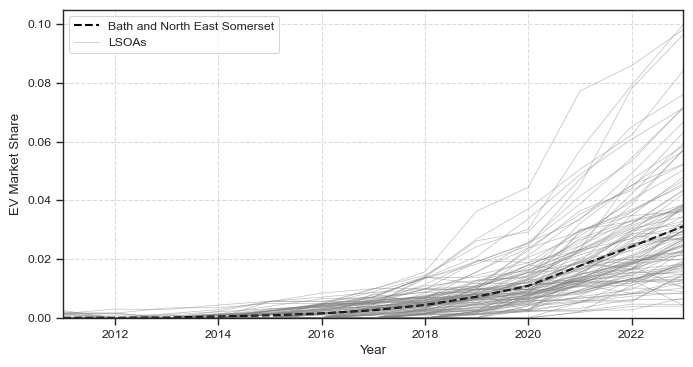

In [4]:
lad = 'Bath and North East Somerset'
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lad_lsoa_dict[lad]['ev_ms'], color='grey', alpha=0.5, lw=0.5)
lad_evms_df[lad].plot(ax=ax, legend=True, color='Black', lw=1.5, linestyle='--')
ax.plot(lad_evms_df[lad], color='grey', alpha=0.5, lw=0.5, label='LSOAs')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('EV Market Share')
plt.xlim(2011, 2023)
plt.ylim(bottom=0)
plt.legend()
plt.show()

# Developing a Custom Mean Function

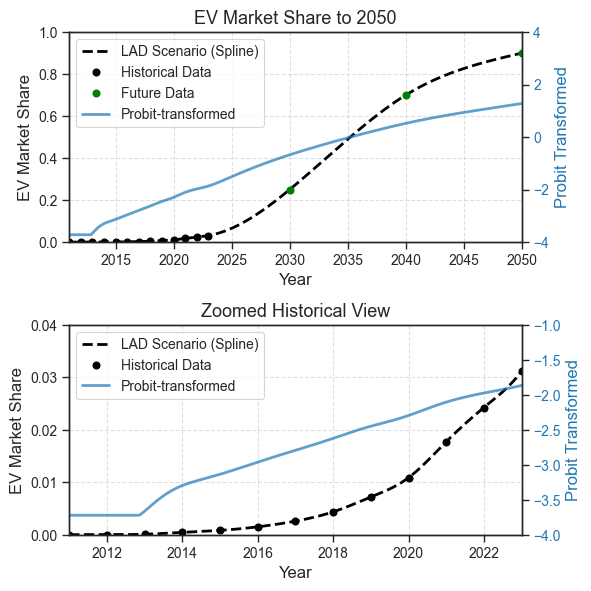

In [186]:
# Example future scenario points
future_points = {
    2030: 0.25,
    2040: 0.7,
    2050: 0.9
}

# LAD to plot
lad = 'Bath and North East Somerset'

# Combine historical and scenario data
lad_evms_df_scenario = pd.concat([lad_evms_df[lad], pd.Series(future_points)])
x = lad_evms_df_scenario.index
y = lad_evms_df_scenario.values

# Fit spline
spl = Spline(x, y)
spl.fit_spline()

# New x-axis values for smooth plotting
x_new = np.linspace(2011, 2050, 1000)
y_spline = spl.evaluate(x_new)
y_probit = probit(y_spline)

# Plot setup
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharey=False)

# Plot 1: Full range to 2050
ax1 = axes[0]
ax1.plot(x_new, y_spline, '--', color='black', lw=2, label='LAD Scenario (Spline)')
ax1.plot(x[:-3], y[:-3], 'o', color='black', label='Historical Data')
ax1.plot(x[-3:], y[-3:], 'o', color='green', label='Future Data')
ax1.set_xlim(2011, 2050)
ax1.set_ylim(0, 1)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('EV Market Share', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.tick_params(labelsize=10)

# Twin y-axis for probit
ax1b = ax1.twinx()
ax1b.plot(x_new, y_probit, color='C0', lw=2, alpha=0.7, label='Probit-transformed')
ax1b.set_ylabel('Probit Transformed', color='C0', fontsize=12)
ax1b.tick_params(axis='y', labelcolor='C0', labelsize=10)
ax1b.set_ylim(-4, 4)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, loc='upper left', fontsize=10)
ax1.set_title('EV Market Share to 2050', fontsize=13)

# Plot 2: Zoomed in to 2023
ax2 = axes[1]
ax2.plot(x_new, y_spline, '--', color='black', lw=2, label='LAD Scenario (Spline)')
ax2.plot(x[:-3], y[:-3], 'o', color='black', label='Historical Data')
ax2.set_xlim(2011, 2023)
ax2.set_ylim(0, 0.04)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('EV Market Share', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(labelsize=10)

# Twin y-axis for probit
ax2b = ax2.twinx()
ax2b.plot(x_new, y_probit, color='C0', lw=2, alpha=0.7, label='Probit-transformed')
ax2b.set_ylabel('Probit Transformed', color='C0', fontsize=12)
ax2b.tick_params(axis='y', labelcolor='C0', labelsize=10)
ax2b.set_ylim(-4, -1)

# Legend
lines2, labels2 = ax2.get_legend_handles_labels()
lines2b, labels2b = ax2b.get_legend_handles_labels()
ax2.legend(lines2 + lines2b, labels2 + labels2b, loc='upper left', fontsize=10)
ax2.set_title('Zoomed Historical View', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/example_transformed_mean_function.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

# Example Use of GP Forecasting Model

### Use JointGPForecaster Class to Train the GP Models

In [178]:
t_dict = {
    't_0': 2011,
    't_n': 2018,
    't_f': 2023
}

joint_gp_forecaster = JointGPForecaster(
    GPForecastingModelClass=GPForecastingModel,
    region='Bath and North East Somerset',
    region_neighbourhood_dict=lad_lsoa_dict,
    region_evms_df=lad_evms_df,
    t_dict=t_dict,
    future_regional_data=None,
    kernel_prior=gpflow.kernels.RBF(
        lengthscales=gpflow.Parameter(f64(10.0), prior=tfp.distributions.Gamma(f64(10.0), f64(1.0)), transform=tfp.bijectors.Softplus()),
        variance=gpflow.Parameter(f64(0.3), prior=tfp.distributions.Gamma(f64(3.0), f64(10.0)), transform=tfp.bijectors.Softplus())
    ),
    likelihood_prior=gpflow.likelihoods.Gaussian(
        variance=gpflow.Parameter(f64(0.005), prior=tfp.distributions.Gamma(f64(2.0), f64(100.0)), transform=tfp.bijectors.Softplus())
    )
)

joint_gp_forecaster.train()

Summary of optimised hyperparameters

In [179]:
gpflow.utilities.print_summary(joint_gp_forecaster.models[1].gp_model)

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,Gamma,True,(),float64,0.233831
GPR.kernel.lengthscales,Parameter,Softplus,Gamma,True,(),float64,6.67761
GPR.likelihood.variance,Parameter,Softplus + Shift,Gamma,True,(),float64,0.00550078


Plotting an example forecast

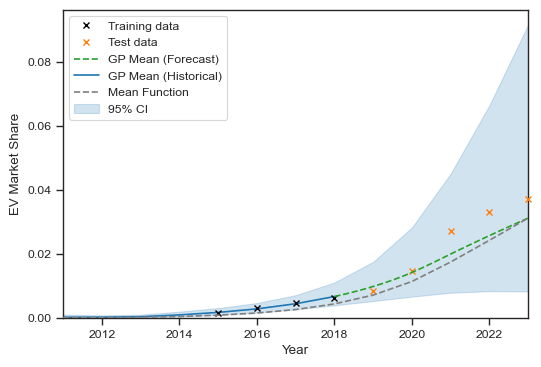

In [ ]:
t_dict = {
    't_0': 2011,
    't_n': 2018,
    't_f': 2023
}

X_new = np.linspace(t_dict['t_n'], t_dict['t_f'] + 1, 100)[:, None].astype(np.float64)
X_plot = np.arange(t_dict['t_0'], t_dict['t_f'] + 1)[:, None]

joint_gp_forecaster.models[18].plot_forecast(
    X_plot=X_plot,
    X_new=X_new,
    probit_transform=False
)

### Calculating and Storing forecast Means, Variances and Sample Tragectories

In [181]:
forecast_mean_df, forecast_var_df = joint_gp_forecaster.run_forecasts(t_dict={
    't_0': 2011,
    't_n': 2018,
    't_f': 2023}
)

In [182]:
forecast_mean_df

,E01014370,E01014371,E01014372,E01014373,E01014374,E01014375,E01014376,E01014377,E01014379,E01014380,...,E01014478,E01014479,E01014480,E01014481,E01014482,E01014483,E01014484,E01033078,E01033079,E01033080
2019,-2.475438,-3.510635,-2.339626,-2.600684,-2.571987,-2.047150,-2.146819,-2.257364,-2.435415,-2.076940,...,-2.458877,-2.211429,-2.506678,-3.510635,-1.924978,-2.027278,-2.120383,-2.052797,-2.272098,-2.436271
2020,-2.428299,-3.302438,-2.175712,-2.406493,-2.394840,-1.872481,-2.021586,-2.084920,-2.276138,-1.839647,...,-2.267487,-2.126321,-2.314991,-3.302438,-1.724522,-1.857256,-1.934496,-1.883276,-2.127987,-2.369116
2021,-2.363795,-3.078159,-2.017994,-2.216186,-2.220047,-1.712159,-1.902854,-1.919277,-2.115901,-1.621285,...,-2.083010,-2.039612,-2.129112,-3.078159,-1.549506,-1.702381,-1.762911,-1.728377,-1.992252,-2.284013
2022,-2.305575,-2.869100,-1.893603,-2.058746,-2.075767,-1.593331,-1.815436,-1.788845,-1.983200,-1.452875,...,-1.934043,-1.974679,-1.977740,-2.869100,-1.426526,-1.589291,-1.633350,-1.614613,-1.889972,-2.206550
2023,-2.246357,-2.673883,-1.796126,-1.929428,-1.956705,-1.508991,-1.751011,-1.688167,-1.873351,-1.330223,...,-1.815299,-1.922745,-1.855750,-2.673883,-1.347161,-1.510474,-1.539263,-1.534445,-1.812849,-2.131267


Forecasts are generated in probit space. To return forecast means in the regular EVMS space, we must apply an inverse probit transform.

In [183]:
forecast_mean_df.apply(invprobit)

,E01014370,E01014371,E01014372,E01014373,E01014374,E01014375,E01014376,E01014377,E01014379,E01014380,...,E01014478,E01014479,E01014480,E01014481,E01014482,E01014483,E01014484,E01033078,E01033079,E01033080
2019,0.006654,0.000224,0.009652,0.004652,0.005056,0.020322,0.015904,0.011993,0.007437,0.018904,...,0.006969,0.013503,0.006094,0.000224,0.027116,0.021317,0.016987,0.020046,0.011540,0.007420
2020,0.007585,0.000479,0.014788,0.008053,0.008314,0.030570,0.021610,0.018538,0.011419,0.032910,...,0.011680,0.016738,0.010307,0.000479,0.042307,0.031637,0.026526,0.029831,0.016669,0.008915
2021,0.009044,0.001041,0.021796,0.013339,0.013208,0.043434,0.028530,0.027475,0.017177,0.052478,...,0.018625,0.020694,0.016622,0.001041,0.060630,0.044342,0.038958,0.041960,0.023172,0.011185
2022,0.010567,0.002058,0.029139,0.019759,0.018958,0.055543,0.034728,0.036820,0.023673,0.073129,...,0.026554,0.024152,0.023979,0.002058,0.076858,0.055997,0.051198,0.053197,0.029381,0.013673
2023,0.012341,0.003749,0.036237,0.026839,0.025191,0.065651,0.039972,0.045690,0.030510,0.091722,...,0.034739,0.027256,0.031745,0.003749,0.088964,0.065461,0.061870,0.062460,0.034928,0.016534


Generating 1000 example forecast trajectories.

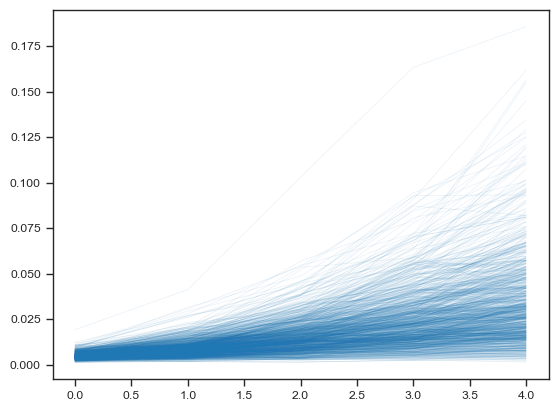

In [184]:
forecast_samples = joint_gp_forecaster.generate_forecast_samples(t_dict={
    't_0': 2011,
    't_n': 2018,
    't_f': 2023},
)

lsoa_idx = 'E01014373'
plt.plot(forecast_samples[lsoa_idx].T, c='C0', alpha=0.1, lw=0.5)
plt.show()

# LSOA and LAD Clustering

### Create a Combined LSOA-level Dataset

In [13]:
lsoa_df = pd.concat([
    data['ev_ms'].T.assign(LAD=lad).rename_axis('LSOA Code') 
    for lad, data in lad_lsoa_dict.items()
]).set_index('LAD', append=True).dropna()

### Calculate Silhouette Scores

In [22]:
def calc_silhouette_scores(X: np.ndarray, k_range = range(2, 10)):
    sil_scores = []
    k_range = range(2, 10)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X)
        sil_score = silhouette_score(X, labels)
        sil_scores.append(sil_score)
        
    plt.plot(k_range, sil_scores, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True)
    plt.show()

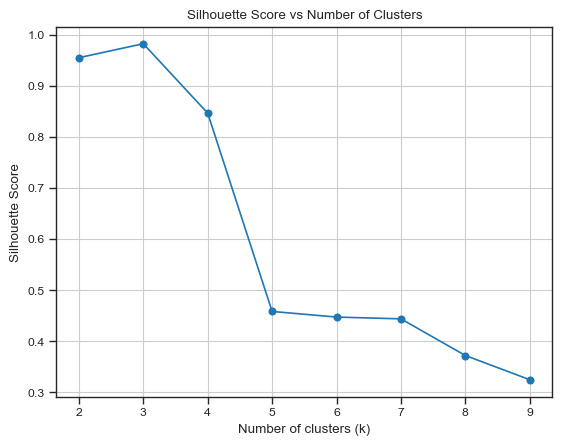

In [23]:
calc_silhouette_scores(X = lsoa_df.iloc[:, :-1].values)

### Cluster LSOA EV Adoption Profiles

In [24]:
# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
lsoa_df['cluster_raw'] = kmeans.fit_predict(lsoa_df.iloc[:, :-1].values)

# Order clusters by final year EVMS
final_year = lsoa_df.columns[-2]
cluster_means = lsoa_df.groupby('cluster_raw')[final_year].mean()
cluster_order = {raw: i for i, raw in enumerate(cluster_means.sort_values().index)}
label_names = {0: 'Low', 1: 'Medium', 2: 'High'}

# Map to ordered and named clusters
lsoa_df['cluster'] = lsoa_df['cluster_raw'].map(cluster_order).map(label_names)

print(100*lsoa_df['cluster'].value_counts() / len(lsoa_df))

cluster
Low       70.193377
Medium    27.122204
High       2.684419
Name: count, dtype: float64


### Plot LSOA EV Adoption Clusters

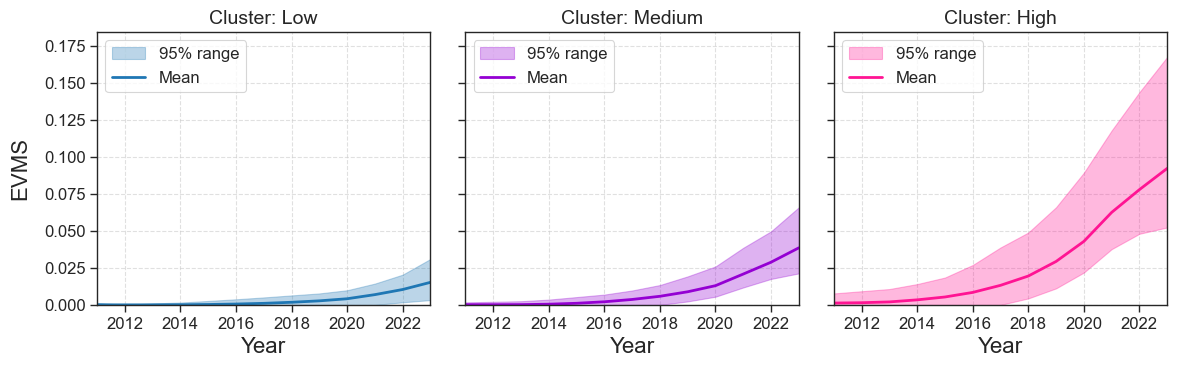

In [25]:
# Ensure years are strings if they are column names
years = lsoa_df.columns[:-2].astype(int).values

# Plotting colors
# plot_colors = {'Low': 'C0', 'Medium': 'C1', 'High': 'C2'}
plot_colors = {'Low': 'C0', 'Medium': 'darkviolet', 'High': 'deeppink'}
alpha_95pi = 0.3

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True) 

# Find the overall maximum value for consistent y-axis scaling if sharey=True
max_upper_bound = 0
for label in ['Low', 'Medium', 'High']:
    cluster_data = lsoa_df[lsoa_df['cluster'] == label].loc[:, years]
    max_upper_bound = max(max_upper_bound, cluster_data.quantile(0.975).max())

# Iterate through clusters and their corresponding axes
for i, label in enumerate(['Low', 'Medium', 'High']):
    ax = axes[i] # Get the current subplot axis
    
    cluster_data = lsoa_df[lsoa_df['cluster'] == label].loc[:, years]
    mean_profile = cluster_data.mean()
    
    lower_bound_95pi = cluster_data.quantile(0.025) 
    upper_bound_95pi = cluster_data.quantile(0.975)
    
    ax.fill_between(years, lower_bound_95pi, upper_bound_95pi, 
                    color=plot_colors[label], alpha=alpha_95pi, label=f'95% range') 

    ax.plot(years, mean_profile, label='Mean', c=plot_colors[label], lw=2)
    ax.set_title(f'Cluster: {label}', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', fontsize=12)
    ax.set_ylim(0, max_upper_bound * 1.1) # Adjust multiplier as needed

    if i==0:
        ax.set_ylabel("EVMS", fontsize=16, labelpad=10)
    ax.set_xlabel("Year", fontsize=16)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

plt.xlim(2011, 2023)
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout
plt.savefig('../figures/lsoa_cluster_profiles.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

### Calculate LAD Mix of LSOA EV Adoption Profiles

In [26]:
cluster_counts = lsoa_df.groupby(['LAD', 'cluster']).size().unstack(fill_value=0)
cluster_counts = cluster_counts[['Low', 'Medium', 'High']]
cluster_proportions = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
cluster_proportions = cluster_proportions.sort_index()
cluster_proportions.head()

cluster,Low,Medium,High
LAD,,,
Adur,0.857143,0.142857,0.0
Allerdale,0.936170,0.063830,0.0
Amber Valley,0.857143,0.142857,0.0
Arun,0.865169,0.134831,0.0
Ashfield,0.942857,0.057143,0.0


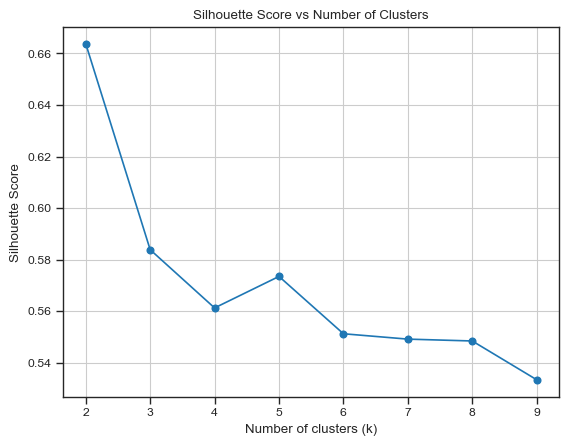

In [27]:
calc_silhouette_scores(
    X = cluster_proportions.drop(columns=['lad_cluster_raw', 'lad_cluster'], errors='ignore').values
)

### Cluster LADs Based on LSOA EV Adoption Profile Mix

In [28]:
kmeans_lad = KMeans(n_clusters=4, random_state=42)
lad_labels = kmeans_lad.fit_predict(cluster_proportions.values)
cluster_proportions['lad_cluster_raw'] = lad_labels
lad_label_names = {0: 'H', 3: 'H-M', 1: 'L-M', 2: 'L'}
cluster_proportions['lad_cluster'] = cluster_proportions['lad_cluster_raw'].map(lad_label_names)

print(100*cluster_proportions['lad_cluster'].value_counts().sort_index() / len(cluster_proportions['lad_cluster']))

cluster_proportions.head()

lad_cluster
H       8.459215
H-M    18.429003
L      47.734139
L-M    25.377644
Name: count, dtype: float64


cluster,Low,Medium,High,lad_cluster_raw,lad_cluster
LAD,,,,,
Adur,0.857143,0.142857,0.0,2,L
Allerdale,0.936170,0.063830,0.0,2,L
Amber Valley,0.857143,0.142857,0.0,2,L
Arun,0.865169,0.134831,0.0,2,L
Ashfield,0.942857,0.057143,0.0,2,L


### Plot LAD Clusters

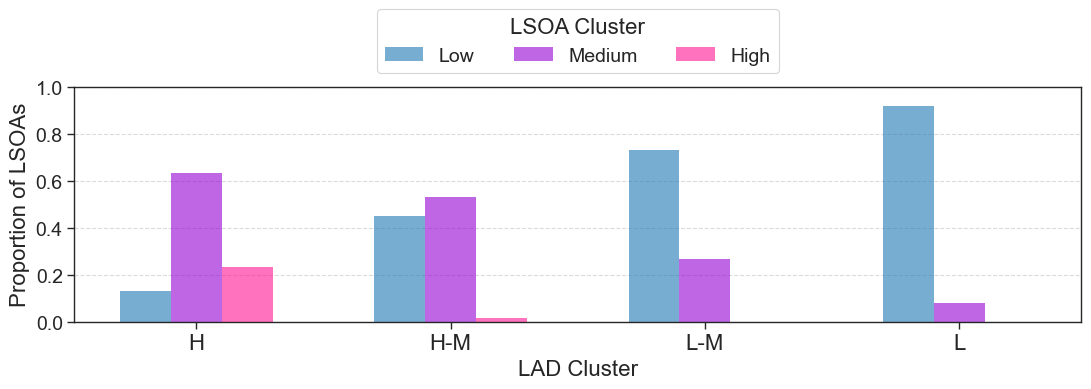

In [29]:
lad_cluster_labels = ['H', 'H-M', 'L-M', 'L']
evms_level_labels = ['Low', 'Medium', 'High']
evms_level_colors = ['C0', 'darkviolet', 'deeppink']
bar_width = 0.2

summary_df = (cluster_proportions.groupby('lad_cluster').mean().reindex(lad_cluster_labels))
x = np.arange(len(lad_cluster_labels))

fig, ax = plt.subplots(figsize=(11, 4))

for i, evms_level in enumerate(evms_level_labels):
    ax.bar(
        x + i * bar_width,
        summary_df[evms_level],
        width=bar_width,
        label=evms_level,
        color=evms_level_colors[i],
        alpha=0.6,
        edgecolor='None',
        linewidth=1
    )

ax.set_ylabel('Proportion of LSOAs', fontsize=16)
ax.set_xlabel('LAD Cluster', fontsize=16)
ax.set_xticks(x + bar_width)
ax.set_xticklabels(lad_cluster_labels, fontsize=16)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.tick_params(axis='y', labelsize=14)
ax.legend(
    title='LSOA Cluster',
    title_fontsize=16,
    fontsize=14,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True
)

plt.tight_layout()
plt.savefig('../figures/lad_cluster_profiles_bar.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

# Identifying Representative LADs

### Calculating Upper and Lower Quartiles

In [30]:
cluster_evms_quartiles = pd.DataFrame(index = lad_cluster_labels, columns=['25th', '75th'])
for cluster in lad_cluster_labels:
    cluster_data = lad_evms_df.loc[2023].loc[cluster_proportions[cluster_proportions['lad_cluster'] == cluster].index]
    p25 = cluster_data.quantile(0.25, interpolation='nearest')
    p75 = cluster_data.quantile(0.75, interpolation='nearest')
    cluster_evms_quartiles.loc[cluster, '25th'] = p25
    cluster_evms_quartiles.loc[cluster, '75th'] = p75

cluster_evms_quartiles

,25th,75th
H,0.039812,0.058434
H-M,0.028326,0.034659
L-M,0.020512,0.023261
L,0.013112,0.017011


### Select LADs from each Cluster, closest to these quartiles

In [31]:
cluster_evms_lad_names = {}
lad_list = []

# Subset 2023 LAD data
lad_ev_2023 = lad_evms_df.loc[2023]

for cluster in lad_cluster_labels:
    # Subset LADs for the current cluster
    cluster_lads = lad_ev_2023[cluster_proportions['lad_cluster'] == cluster]
    
    # Find LAD closest to 25th and 75th percentile EV market share
    p25_target = cluster_evms_quartiles.loc[cluster, '25th']
    p75_target = cluster_evms_quartiles.loc[cluster, '75th']
    
    # Use absolute difference to find nearest LAD
    p25_lad = cluster_lads.index[(cluster_lads - p25_target).abs().argmin()]
    p75_lad = cluster_lads.index[(cluster_lads - p75_target).abs().argmin()]
    lad_list.append(p75_lad)
    lad_list.append(p25_lad)
    
    cluster_evms_lad_names[cluster] = {
        '25th': p25_lad,
        '75th': p75_lad
    }

# Display as DataFrame
cluster_evms_lad_names = pd.DataFrame(cluster_evms_lad_names)
print(lad_list)
cluster_evms_lad_names

['Wandsworth', 'Hackney', 'Hillingdon', 'Harrogate', 'South Gloucestershire', 'Charnwood', 'Crawley', 'Dudley']


,H,H-M,L-M,L
25th,Hackney,Harrogate,Charnwood,Dudley
75th,Wandsworth,Hillingdon,South Gloucestershire,Crawley


### Select LADs with the highest and lowest EVMS

We exclude the the Isles of Scilly and the City of London due to their small number of LSOAs.

In [32]:
lad_evms_df.drop("Isles of Scilly", axis=1).loc[2023].sort_values(ascending=True).head()

LAD
Blaenau Gwent                  0.006361
Kingston upon Hull, City of    0.007890
Merthyr Tydfil                 0.007915
Middlesbrough                  0.008776
Sandwell                       0.009070
Name: 2023, dtype: float64

In [33]:
lad_evms_df.drop("Isles of Scilly", axis=1).loc[2023].sort_values(ascending=True).tail()

LAD
Hammersmith and Fulham    0.067388
Camden                    0.092768
Kensington and Chelsea    0.100393
Westminster               0.103653
City of London            0.106667
Name: 2023, dtype: float64

### Create LAD List

In [34]:
lad_array = np.insert(np.array(lad_list, dtype=object), 0, 'Westminster')
lad_array = np.insert(lad_array, 9, 'Blaenau Gwent')
lad_array

array(['Westminster', 'Wandsworth', 'Hackney', 'Hillingdon', 'Harrogate',
       'South Gloucestershire', 'Charnwood', 'Crawley', 'Dudley',
       'Blaenau Gwent'], dtype=object)

In [35]:
lad_evms_df.drop("Isles of Scilly", axis=1).loc[2023, lad_array]

LAD
Westminster              0.103653
Wandsworth               0.058434
Hackney                  0.039812
Hillingdon               0.034659
Harrogate                0.028326
South Gloucestershire    0.023261
Charnwood                0.020512
Crawley                  0.017011
Dudley                   0.013112
Blaenau Gwent            0.006361
Name: 2023, dtype: float64

Plotting the historical EVMS trajectories of the representative LADs

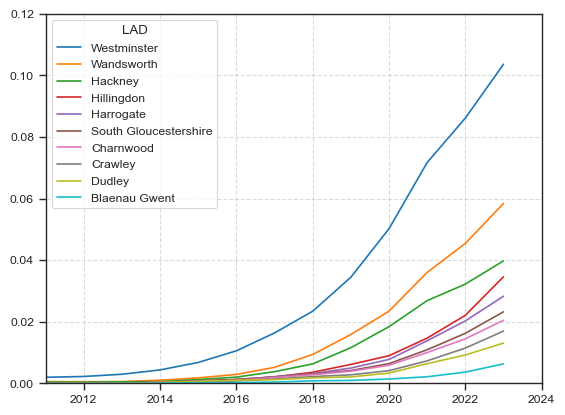

In [36]:
lad_evms_df[lad_array].plot()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.xlim(2011, 2024)
plt.ylim(0, 0.12)
plt.show()

# Visualising LAD Clusters

### Load LAD Boundaries

In [37]:
lad_boundaries = gpd.read_file(filename='../data/lad_boundaries/LAD_DEC_22_UK_BUC_V2/LAD_DEC_2022_UK_BUC_V2.shp')
lad_boundaries.set_index('LAD22NM', inplace=True)
lad_boundaries.drop(columns=['BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID'], inplace=True)
crs = 25832 # Units of meters
lad_boundaries.to_crs(crs, inplace=False)
lad_boundaries.head()

,LAD22CD,geometry
LAD22NM,,
Hartlepool,E06000001,"POLYGON ((448973.593 536745.277, 448986.025 53..."
Middlesbrough,E06000002,"POLYGON ((451894.299 521145.303, 453997.697 51..."
Redcar and Cleveland,E06000003,"POLYGON ((478232.568 518788.831, 477689.303 51..."
Stockton-on-Tees,E06000004,"POLYGON ((452243.536 526335.188, 451711.3 5256..."
Darlington,E06000005,"POLYGON ((436388.002 522354.197, 437351.702 52..."


### Add Boundaries to LAD EVMS Cluster Data

In [38]:
lad_evms_df_geo = gpd.GeoDataFrame(data=lad_evms_df.loc[2023], geometry=lad_boundaries.loc[lad_evms_df.columns].geometry)
lad_evms_df_geo['lad_cluster'] = cluster_proportions['lad_cluster']
lad_evms_df_geo['lad_cluster'] = pd.Categorical(lad_evms_df_geo['lad_cluster'], categories=lad_cluster_labels, ordered=True)
lad_evms_df_geo.head()

,2023,geometry,lad_cluster
LAD,,,
City of London,0.106667,"POLYGON ((533333.512 180406.663, 531312.717 18...",H
Barking and Dagenham,0.030715,"POLYGON ((549991.888 181417.594, 549894.994 18...",H-M
Barnet,0.055727,"POLYGON ((525814.1 198211.502, 525568.603 1975...",H
Bexley,0.026448,"POLYGON ((550181.054 180645.809, 550636.764 18...",H-M
Brent,0.046732,"POLYGON ((523951.697 185545.497, 525530 183481...",H


### Plot LSOA EV Adoption Trajectories for each LAD

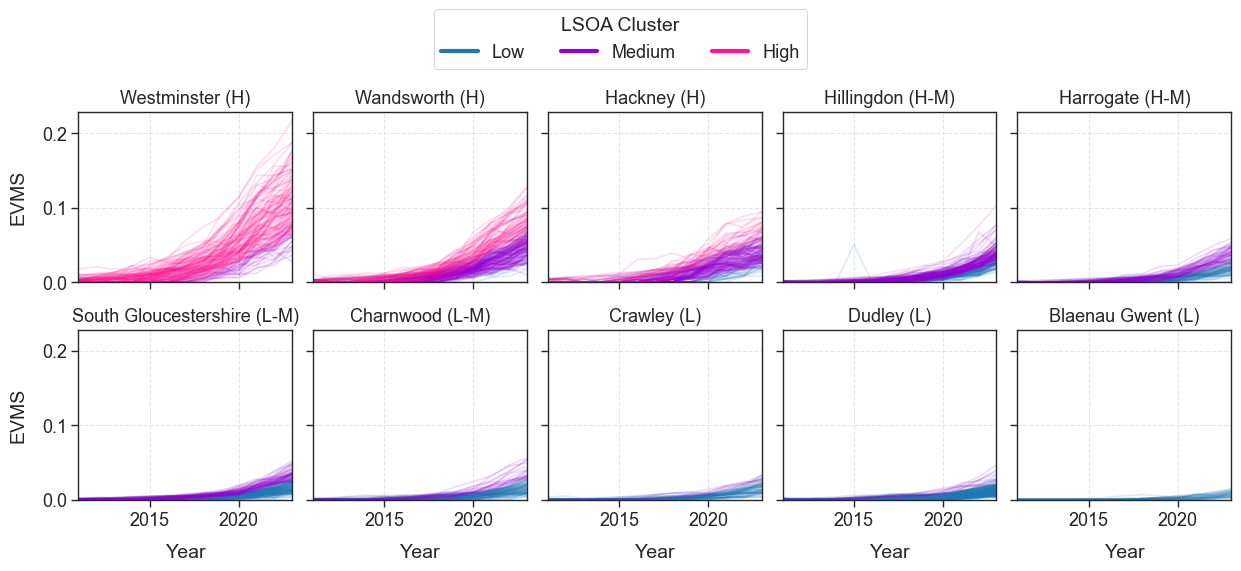

In [39]:
plot_colors = {'Low': 'C0', 'Medium': 'C1', 'High': 'C2'}
plot_colors = {'Low': 'C0', 'Medium': 'darkviolet', 'High': 'deeppink'}

n_lads = len(lad_array)
n_cols = 5
n_rows = (n_lads + n_cols - 1) // n_cols  # Round up to ensure enough rows

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for idx, lad in enumerate(lad_array):
    ax = axes[idx]
    lsoa_data = lsoa_df.xs(lad, level='LAD')
    years = lsoa_data.columns[:-2].astype(int)

    for cluster_label in ['Low', 'Medium', 'High']:
        cluster_data = lsoa_data[lsoa_data['cluster'] == cluster_label]
        X = cluster_data.iloc[:, :-2].values

        for row in X:
            ax.plot(years, row, color=plot_colors[cluster_label], alpha=0.15)

    lad_cluster = cluster_proportions['lad_cluster'].loc[lad]
    ax.set_xlim(2011, 2023)
    ax.set_title(f"{lad} ({lad_cluster})", fontsize=13)
    ax.grid(axis='both', linestyle='--', alpha=0.5)
    if idx % n_cols == 0:
        ax.set_ylabel("EVMS", fontsize=14, labelpad=10)
    if idx >= n_cols * (n_rows - 1):
        ax.set_xlabel("Year", fontsize=14, labelpad=10)
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)

# Create legend
handles = []
labels = []
for label in plot_colors:
    # Plot an invisible line to capture a handle
    handle, = plt.plot([], [], color=plot_colors[label], label=label, linewidth=3)
    handles.append(handle)
    labels.append(label)

# Add the shared legend
fig.legend(
    handles=handles,
    labels=labels,
    title="LSOA Cluster",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    fontsize=13,
    title_fontsize=14
)

plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('../figures/selected_lad_profiles_horizontal.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

### Plot LAD Clusters on Map

In [40]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    """Truncate a colormap from minval to maxval (values between 0 and 1)."""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

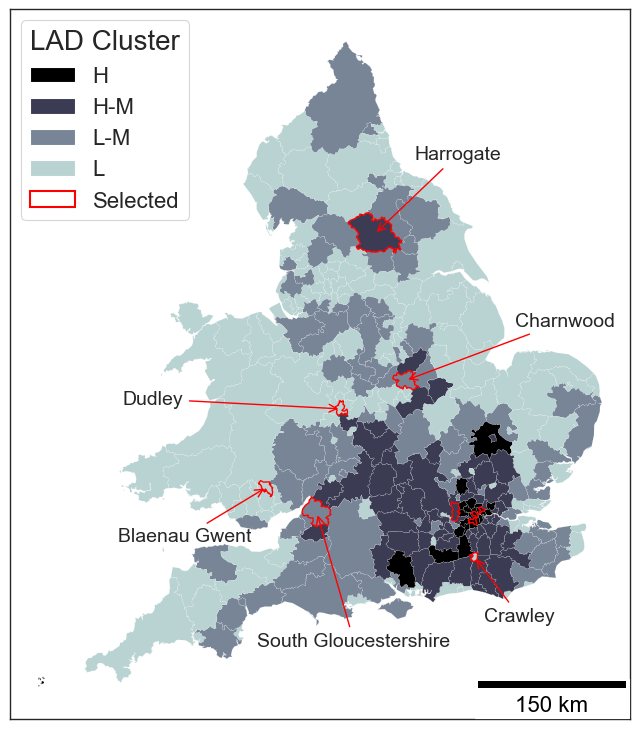

In [41]:
original_cmap = plt.get_cmap('bone')
truncated_cmap = truncate_colormap(original_cmap, minval=0, maxval=0.8)

fig, ax = plt.subplots(figsize=[8, 12])

# Plot LAD choropleth without automatic legend
lad_evms_df_geo.plot(
    column='lad_cluster',
    cmap=truncated_cmap,
    ax=ax,
    edgecolor="white",
    linewidth=0.1
)

# Highlight selected LADs
lad_evms_df_geo.loc[lad_array].plot(
    ax=ax,
    facecolor='none',
    edgecolor="red",
    linewidth=1
)

cluster_values = np.array(lad_cluster_labels)
colors = truncated_cmap(np.linspace(0, 1, len(cluster_values)))
cluster_patches = [Patch(facecolor=color, edgecolor='white', label=f'{val}') for val, color in zip(cluster_values, colors)]

# Add red highlight patch
highlight_patch = Patch(facecolor='none', edgecolor='red', linewidth=1.5, label='Selected')

# Combine and create legend
handles = cluster_patches + [highlight_patch]

ax.legend(
    handles=handles, 
    title="LAD Cluster", 
    title_fontsize=20, 
    fontsize=16, 
    loc='upper left'
)

# Remove ticks and add scalebar
ax.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)
ax.add_artist(ScaleBar(1, units='m', length_fraction=0.3, location='lower right', font_properties={"size": 16}))

offsets = {
    'Harrogate': (40000, 80000), 
    'South Gloucestershire': (-60000, -130000), 
    'Charnwood': (110000, 60000), 
    'Crawley': (10000, -60000),
    'Dudley': (-220000, 10000),
    'Blaenau Gwent': (-150000, -50000)
}

# Annotate selected LADs
for lad_code in ['Harrogate', 'South Gloucestershire', 'Charnwood', 'Crawley', 'Dudley', 'Blaenau Gwent']:
    row = lad_evms_df_geo.loc[lad_code]
    centroid = row.geometry.centroid
    label = row.name 
    offset = offsets[lad_code]
    
    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        xytext=(centroid.x + offset[0], centroid.y + offset[1]),
        textcoords='data',
        arrowprops=dict(arrowstyle="->", color='red', linewidth=1),
        fontsize=14,
        ha='left',
        va='center'
    )

plt.savefig('../figures/lad_clusters_map.png', bbox_inches="tight", pad_inches=0.2, dpi=300)

plt.show()

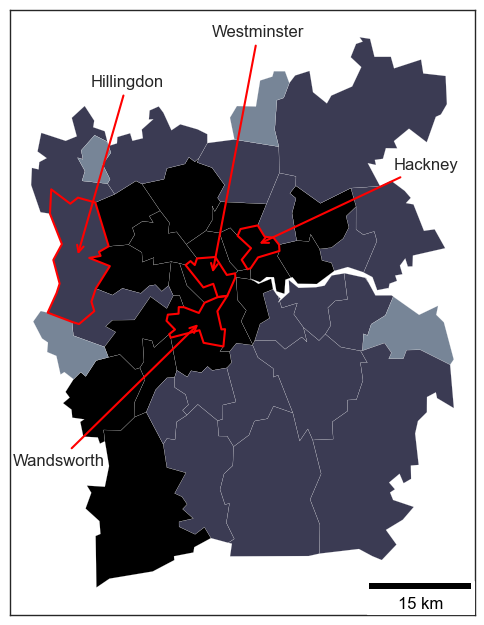

In [42]:
# Define a bounding box around Greater London (approximate)
london_bounds = {
    'minx': 510000,
    'maxx': 550000,
    'miny': 160000,
    'maxy': 200000
}

# Filter for LADs in the London area
london_lads = lad_evms_df_geo.cx[
    london_bounds['minx']:london_bounds['maxx'],
    london_bounds['miny']:london_bounds['maxy']
]

# Plot
fig, ax = plt.subplots(figsize=[6, 8])

london_lads.plot(
    column='lad_cluster',
    cmap=truncated_cmap,
    ax=ax,
    edgecolor="white",
    linewidth=0.1
)

# Highlight selected LADs in London
selected_london_lads = london_lads[london_lads.index.isin(lad_array)]
selected_london_lads.plot(
    ax=ax,
    facecolor='none',
    edgecolor="red",
    linewidth=1.5
)

offsets = {
    'Westminster': (0, 35000), 
    'Wandsworth': (-27500, -21000), 
    'Hackney': (20000, 11000), 
    'Hillingdon': (2000, 25000),
}

# Add annotations
for idx, row in selected_london_lads.iterrows():
    centroid = row.geometry.centroid
    label = row.name
    offset = offsets[label]
    
    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        xytext=(centroid.x + offset[0], centroid.y + offset[1]),
        textcoords='data',
        arrowprops=dict(arrowstyle="->", color='red', linewidth=1.5),
        fontsize=12,
        ha='left'
    )

# Add scale bar and formatting
ax.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)
ax.add_artist(ScaleBar(1, units='m', length_fraction=0.25, location='lower right', font_properties={"size": 12}))

plt.savefig('../figures/lad_clusters_london_zoom.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

# Calculating the Proportion of Missing Data for each LAD

In [43]:
ev_reg_df_private_raw = lsoa_data_processor.ev_reg_df_raw.query("Fuel == 'Total' & Keepership == 'Private'").drop(columns=['Fuel', 'Keepership', 'LSOA11NM']).set_index('LSOA11CD').iloc[:, ::-1].astype(float)
float_years = ev_reg_df_private_raw.columns.map(lsoa_data_processor._convert_quarter_index_to_float)
ev_reg_df_private_raw.columns = float_years

ev_reg_df_private_raw_full = lsoa_data_processor.ev_reg_df_raw.query("Fuel == 'Total' & Keepership == 'Private'").drop(columns=['Fuel', 'Keepership', 'LSOA11NM']).set_index('LSOA11CD').iloc[:, ::-1].reindex(lsoa_data_processor.ev_reg_private_df.T.index).astype(float)
ev_reg_df_private_raw_full.columns = float_years

lsoa_lookup_df = lsoa_data_processor.lsoa_lookup.set_index('LSOA11CD').copy()
lsoa_lookup_df_filtered = lsoa_lookup_df[lsoa_lookup_df.index.isin(ev_reg_df_private_raw.index)]
lsoa_lookup_df_filtered.head()

,LSOA11NM,LSOA21CD,LSOA21NM,CHGIND,LAD22CD,LAD22NM,LAD22NMW,ObjectId
LSOA11CD,,,,,,,,
E01000001,City of London 001A,E01000001,City of London 001A,U,E09000001,City of London,NaN,1
E01000002,City of London 001B,E01000002,City of London 001B,U,E09000001,City of London,NaN,2
E01000003,City of London 001C,E01000003,City of London 001C,U,E09000001,City of London,NaN,3
E01000005,City of London 001E,E01000005,City of London 001E,U,E09000001,City of London,NaN,4
E01000006,Barking and Dagenham 016A,E01000006,Barking and Dagenham 016A,U,E09000002,Barking and Dagenham,NaN,5


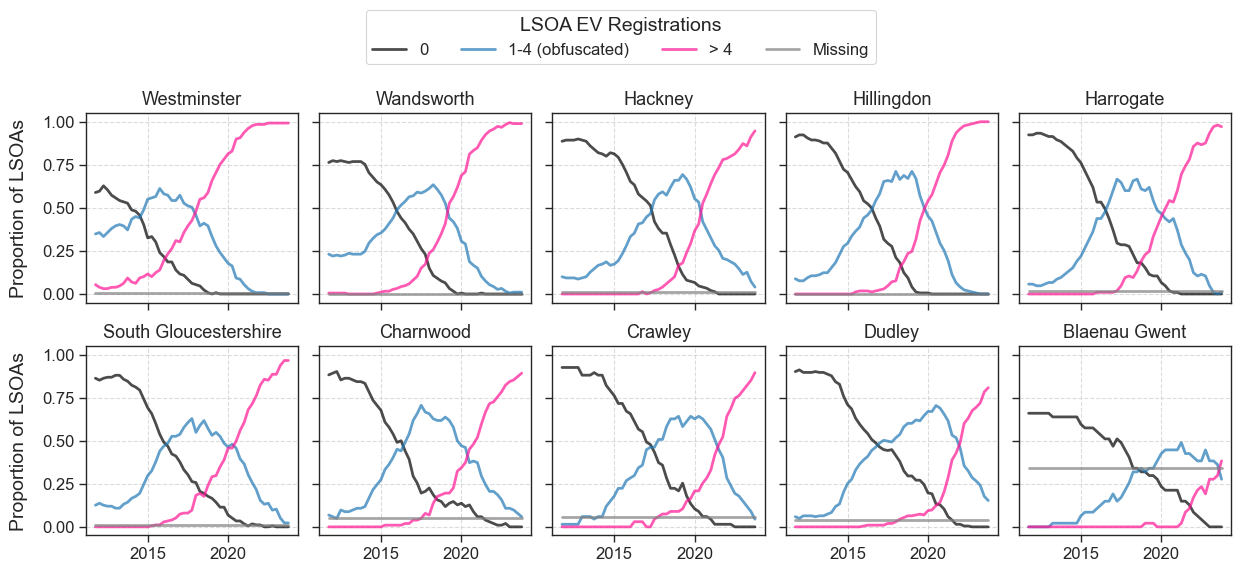

In [44]:
p_obfuscated_df = pd.DataFrame(index=ev_reg_df_private_raw.columns, columns=lad_array)
p_zero_df = pd.DataFrame(index=ev_reg_df_private_raw.columns, columns=lad_array)
p_valid_df = pd.DataFrame(index=ev_reg_df_private_raw.columns, columns=lad_array)
p_missing_df = pd.DataFrame(index=ev_reg_df_private_raw_full.columns, columns=lad_array)

for lad in lad_array:
    lsoa_codes_filtered = lsoa_lookup_df_filtered[lsoa_lookup_df_filtered['LAD22NM'] == lad].index.values
    lsoa_codes = lsoa_lookup_df[lsoa_lookup_df['LAD22NM'] == lad].index.values

    p_obfuscated_df[lad] = ev_reg_df_private_raw.loc[lsoa_codes_filtered].isna().sum() / len(lsoa_codes)
    p_zero_df[lad] = ev_reg_df_private_raw.loc[lsoa_codes_filtered].eq(0).sum() / len(lsoa_codes)
    p_valid_df[lad] = (ev_reg_df_private_raw.loc[lsoa_codes_filtered] > 4).sum() / len(lsoa_codes)
    p_missing_df[lad] = (ev_reg_df_private_raw_full.loc[lsoa_codes].isna().sum() - ev_reg_df_private_raw.loc[lsoa_codes_filtered].isna().sum()) / len(lsoa_codes)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12.5, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, lad in enumerate(p_obfuscated_df.columns):
    ax = axes[i]
    
    # Plot proportion of LSOAs with zero EVs
    p_zero_df[lad].plot(
        ax=ax,
        kind='line',
        color='black',
        label='0',
        alpha=0.7,
        linewidth=2,
        clip_on=False
    )

    # Plot proportion of LSOAs with 1–4 EVs (obfuscated)
    p_obfuscated_df[lad].plot(
        ax=ax,
        kind='line',
        color='C0',
        label='1-4 (Obfuscated)',
        alpha=0.7,
        linewidth=2,
        clip_on=False
    )

    p_valid_df[lad].plot(
        ax=ax,
        kind='line',
        color='deeppink',
        label='> 4',
        alpha=0.7,
        linewidth=2,
        clip_on=False
    )

    p_missing_df[lad].plot(
        ax=ax,
        kind='line',
        color='grey',
        label='Missing',
        alpha=0.7,
        linewidth=2,
        clip_on=False
    )

    ax.set_title(f"{lad}", fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion of LSOAs', fontsize=14, labelpad=10)
    ax.grid(axis='both', linestyle='--', alpha=0.7)
    ax.tick_params(axis='both', labelsize=12)

fig.legend(
    handles=axes[0].get_lines(),
    labels=['0', '1-4 (obfuscated)', '> 4', 'Missing'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    title='LSOA EV Registrations',
    ncol=4,
    fontsize=12,
    title_fontsize=14,
)

plt.tight_layout()
plt.savefig('../figures/obfuscated_data.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

# Model Training for Validation

### Training the Models

Uncomment if running for the first time.

In [150]:
forecast_validator = GPForecastValidator(
    GPForecastingModelClass=GPForecastingModel,
    region_evms_df=lad_evms_df,
    region_neighbourhood_dict=lad_lsoa_dict,
    region_list=lad_array,
    t_n_range=range(2018, 2023),
    future_regional_data_dict=None,   # or pass a dict of dicts if you have scenarios
    t_0=2011,
    t_f=2023
)

models_dict = forecast_validator.train_joint_forecasters()

Checking the forecast have been made successfuly.

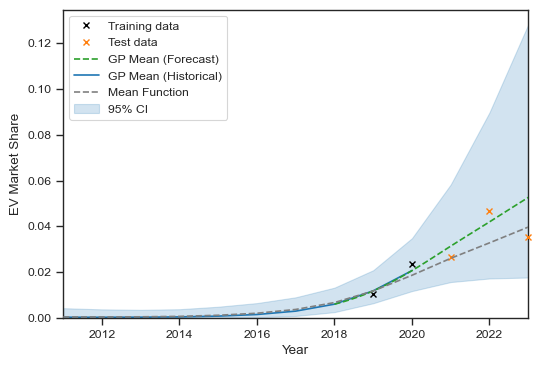

In [151]:
X_new = np.linspace(t_dict['t_n'], t_dict['t_f'] + 1, 100)[:, None].astype(np.float64)
X_plot = np.arange(t_dict['t_0'], t_dict['t_f'] + 1)[:, None]

models_dict[2020]['Hackney'][1].plot_forecast(
    X_plot=X_plot,
    X_new=X_new,
    probit_transform=False
)

### Save forecasters in .pickle file

In [ ]:
with open('../data/forecasters_dict.pkl', 'wb') as f:
    dill.dump(forecast_validator.forecasters_dict, f)

### Load forecasters from .pickle file

Uncomment if models have been trained and saved.

In [ ]:
with open('../data/forecasters_dict.pkl', 'rb') as f:
    forecasters_dict = dill.load(f)

forecast_validator = GPForecastValidator(
    GPForecastingModelClass=GPForecastingModel,
    region_evms_df=lad_evms_df,
    region_neighbourhood_dict=lad_lsoa_dict,
    region_list=lad_array,
    t_n_range=range(2018, 2023),
    future_regional_data_dict=None,   # or pass a dict of dicts if you have scenarios
    t_0=2011,
    t_f=2023
)

forecast_validator.forecasters_dict = forecasters_dict

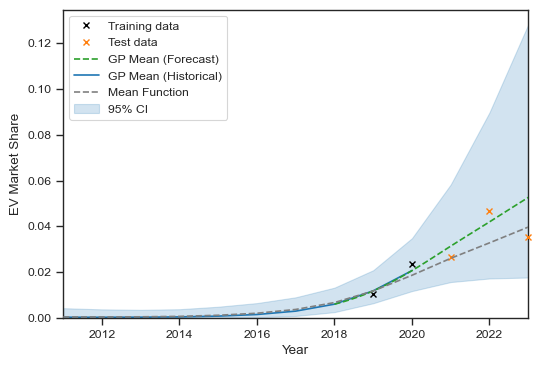

In [ ]:
X_new = np.linspace(t_dict['t_n'], t_dict['t_f'] + 1, 100)[:, None].astype(np.float64)
X_plot = np.arange(t_dict['t_0'], t_dict['t_f'] + 1)[:, None]

forecasters_dict[2020]['Hackney'].models[1].plot_forecast(
    X_plot=X_plot,
    X_new=X_new,
    probit_transform=False
)

Extract forecast means and samples.

In [159]:
mean_dict, var_dict, samples_dict = forecast_validator.extract_forecast_means_variance_and_samples()

### Calculate the Error Metrics

In [160]:
forecast_validator.calculate_error_metrics()

Error metrics stored as: mae_dict, nmae_dict, me_dict, nme_dict


{2018: {2019:                            MAE   nMAE       ME      nME
  Westminster            0.00709  0.206 -0.00098 -0.02835
  Wandsworth             0.00459  0.289 -0.00115 -0.07241
  Hackney                0.00485  0.417 -0.00095 -0.08187
  Hillingdon             0.00212  0.342 -0.00033 -0.05336
  Harrogate              0.00141  0.281 -0.00028 -0.05614
  South Gloucestershire  0.00129  0.306  -0.0004 -0.09584
  Charnwood              0.00106  0.268 -0.00022 -0.05455
  Crawley                0.00101  0.361 -0.00063 -0.22265
  Dudley                 0.00093  0.435 -0.00011 -0.05194
  Blaenau Gwent           0.0006  0.603 -0.00017 -0.17364,
  2020:                            MAE   nMAE       ME      nME
  Westminster            0.01382  0.275 -0.00054  -0.0108
  Wandsworth             0.00956  0.407 -0.00157 -0.06691
  Hackney                0.00994  0.539 -0.00252 -0.13643
  Hillingdon             0.00405   0.45 -0.00024 -0.02705
  Harrogate               0.0034  0.435 -0.00037 -0.0

# Making Baseline Forecasts

### Linear Extrapolation

In [63]:
le_forecaster = BaselineForecaster(model_class=LinearRegression)

le_forecasts_dict = le_forecaster.generate_forecasts(
    lad_lsoa_dict=lad_lsoa_dict, 
    lad_array=lad_array,
    t_s=2016,
    t_n_first=2018,
    t_f_last=2023
)

### Scaled Scenario

In [64]:
ss_forecaster = BaselineForecaster(model_class=ScaledScenario, scenarios=lad_evms_df)

ss_forecasts_dict = ss_forecaster.generate_forecasts(
    lad_lsoa_dict=lad_lsoa_dict, 
    lad_array=lad_array,
    t_s=2016,
    t_n_first=2018,
    t_f_last=2023
)

### Logistic Growth

Example LG Model Fit

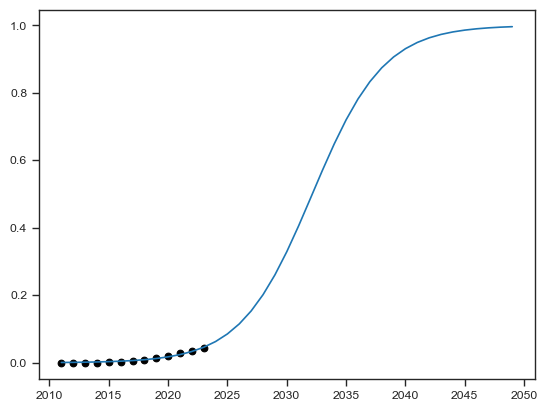

In [65]:
t_s=2011
t_n=2023
t_f_last=2023
lad = 'Hackney'

X_train = np.arange(t_s, t_n + 1).reshape(-1, 1)
X_forecast = np.arange(t_n + 1, t_f_last + 1).reshape(-1, 1)

scenario = lad_lsoa_dict[lad]['ev_ms'].mean(axis=1)
Y_train = scenario.loc[X_train.flatten()].values

model = LogisticGrowthModel()
model.learn_bounds(scenario)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_forecast)

X_plot = np.arange(t_s, 2050)
Y_test = model._logistic(X_plot, k=model.k, t0=model.t0)
plt.scatter(X_train, Y_train, c='k')
plt.plot(X_plot, Y_test),
plt.show()

LG Sensitivity to $k$ and $t_0$ parameters

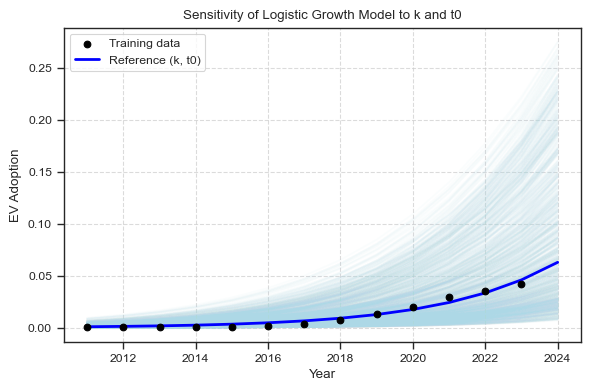

In [66]:
X_plot = np.arange(t_s, 2025)

# Number of curves to sample
n_samples = 1000

# Define parameter bounds
k_min, k_max = model.k - 0.05, model.k + 0.05
t0_min, t0_max = model.t0 - 5, model.t0 + 5

# Sample k and t0 uniformly within the bounds
k_samples = np.random.uniform(k_min, k_max, n_samples)
t0_samples = np.random.uniform(t0_min, t0_max, n_samples)

# Create array to hold results
Y_curves = np.zeros((n_samples, len(X_plot)))

# Generate logistic curves
for i in range(n_samples):
    Y_curves[i] = model._logistic(X_plot, k=k_samples[i], t0=t0_samples[i])

# Plot training data
plt.figure(figsize=(6, 4))
plt.scatter(X_train, Y_train, c='k', label='Training data', zorder=10)

# Plot all sampled curves in light color
for i in range(n_samples):
    plt.plot(X_plot, Y_curves[i], color='lightblue', alpha=0.05)

Y_ref = model._logistic(X_plot, k=model.k, t0=model.t0)

# Plot median or reference curve
plt.plot(X_plot, Y_ref, color='blue', lw=2, label='Reference (k, t0)')
plt.xlabel('Year')
plt.ylabel('EV Adoption')
plt.title('Sensitivity of Logistic Growth Model to k and t0')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [67]:
lg_forecaster = BaselineForecaster(model_class=LogisticGrowthModel, scenarios=lad_evms_df)

lg_forecasts_dict = lg_forecaster.generate_forecasts(
    lad_lsoa_dict=lad_lsoa_dict, 
    lad_array=lad_array,
    t_s=2011,
    t_n_first=2018,
    t_f_last=2023
)

# Evaluating Baselines

In [68]:
baseline_evaluator = BaselineEvaluator(
    lad_lsoa_dict=lad_lsoa_dict,
    lad_evms_df=lad_evms_df,
    lad_array=lad_array,
    t_n_first=2018,
    t_f_last=2023,
    h_f_array=np.arange(1, 6)
)

le_errors_dict = baseline_evaluator.evaluate_forecasts_over_time(forecasts_dict=le_forecasts_dict)
ss_errors_dict = baseline_evaluator.evaluate_forecasts_over_time(forecasts_dict=ss_forecasts_dict)
lg_errors_dict = baseline_evaluator.evaluate_forecasts_over_time(forecasts_dict=lg_forecasts_dict)

In [161]:
gp_nae_dict = baseline_evaluator.compute_nae_over_horizons(forecasts_dict=mean_dict, data_transformation=invprobit)
le_nae_dict = baseline_evaluator.compute_nae_over_horizons(forecasts_dict=le_forecasts_dict)
ss_nae_dict = baseline_evaluator.compute_nae_over_horizons(forecasts_dict=ss_forecasts_dict)
lg_nae_dict = baseline_evaluator.compute_nae_over_horizons(forecasts_dict=lg_forecasts_dict)

### Performing a Baseline Comparison

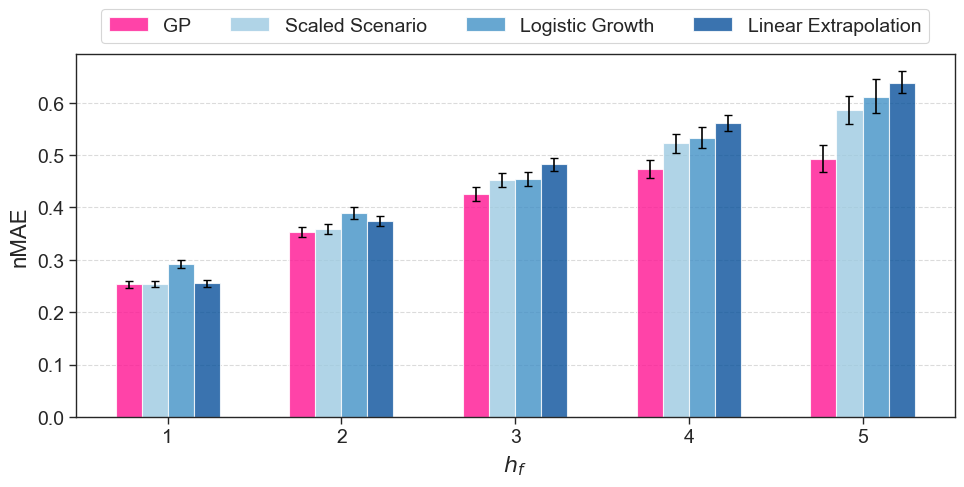

In [162]:
h_f_array=np.arange(1, 6)

baseline_nmae_comparator = BaselineNMAEComparator(iter_array=h_f_array)

gp_nmae_df = baseline_nmae_comparator.compute_bootstrap_results(nae_dict=gp_nae_dict)
le_nmae_df = baseline_nmae_comparator.compute_bootstrap_results(nae_dict=le_nae_dict)
ss_nmae_df = baseline_nmae_comparator.compute_bootstrap_results(nae_dict=ss_nae_dict)
lg_nmae_df = baseline_nmae_comparator.compute_bootstrap_results(nae_dict=lg_nae_dict)

# Combine into one DataFrame
combined_df = pd.concat([
    baseline_nmae_comparator.gather_model_results(gp_nmae_df, 'GP'),
    baseline_nmae_comparator.gather_model_results(ss_nmae_df, 'Scaled Scenario'),
    baseline_nmae_comparator.gather_model_results(lg_nmae_df, 'Logistic Growth'),
    baseline_nmae_comparator.gather_model_results(le_nmae_df, 'Linear Extrapolation') 
], ignore_index=True)

baseline_nmae_comparator.plot_combined_nmae(combined_df, save_file_path='../figures/normalised_mae_baseline_comparison.png')

Breakdown of nMAE and the upper and lower bounds of the 95% confidence intervals.

In [163]:
combined_df

,Horizon,Model,nMAE,Lower CI,Upper CI,yerr_lower,yerr_upper
0,1,GP,0.253286,0.246408,0.260313,0.006878,0.007027
1,2,GP,0.353210,0.343433,0.363515,0.009777,0.010304
2,3,GP,0.425274,0.413012,0.438513,0.012262,0.013239
3,4,GP,0.474141,0.457100,0.491581,0.017041,0.017440
4,5,GP,0.491911,0.467660,0.518799,0.024251,0.026888
5,1,Scaled Scenario,0.253796,0.247272,0.260395,0.006524,0.006600
6,2,Scaled Scenario,0.358650,0.349471,0.367845,0.009179,0.009196
7,3,Scaled Scenario,0.452579,0.439458,0.466105,0.013121,0.013526
8,4,Scaled Scenario,0.523056,0.504631,0.541098,0.018425,0.018042
9,5,Scaled Scenario,0.586282,0.560068,0.613252,0.026214,0.026970


# Plotting Validation Results

### nMAE

In [72]:
def truncate_colormap_discrete(cmap, minval=0.2, maxval=1.0, n=5):
    """Truncate a colormap to exclude light (or dark) ends."""
    new_cmap = [cmap(i) for i in np.linspace(minval, maxval, n)]
    return new_cmap

def calc_mae(predicted: Numeric, actual: Numeric, dp: int = 5) -> Numeric:
    if isinstance(actual, pd.DataFrame) and isinstance(predicted, pd.DataFrame | pd.Series):
        ae = np.abs(actual.sub(predicted, axis=0))
    else:
        ae = np.abs(actual - predicted)

    if isinstance(ae, pd.DataFrame):
        mae = ae.mean(axis=1)
    elif isinstance(ae, pd.Series):
        mae = ae.mean() 
    else:
        mae = np.mean(ae)

    return mae.round(dp) if isinstance(mae, (pd.Series, pd.DataFrame)) else round(mae, dp)

def calc_me(predicted: Numeric, actual: Numeric, dp: int = 5) -> Numeric:

    if isinstance(actual, pd.DataFrame) and isinstance(predicted, pd.DataFrame | pd.Series):
        e = - actual.sub(predicted, axis=0)
    else:
        e = predicted - actual
    
    if isinstance(e, pd.DataFrame):
        me = e.mean(axis=1)
    elif isinstance(e, pd.Series):
        me = e.mean() 
    else:
        me = np.mean(e)

    return me.round(dp) if isinstance(me, (pd.Series, pd.DataFrame)) else round(me, dp)

In [164]:
top_down_estimates_mae = pd.DataFrame(index=lad_array, columns=range(2019, 2024), dtype=float)
for lad in lad_array:
    data = lad_lsoa_dict[lad]['ev_ms']
    data = data.loc[:, data.notna().any()]
    mae = calc_mae(predicted=lad_evms_df[lad], actual=data)
    top_down_estimates_mae.loc[lad] = mae

top_down_estimates_nmae = top_down_estimates_mae.div(lad_evms_df[lad_array].T.loc[:, 2019:])
top_down_estimates_nmae

,2019,2020,2021,2022,2023
Westminster,0.417710,0.388142,0.341867,0.329483,0.286147
Wandsworth,0.458799,0.412534,0.394167,0.367662,0.320019
Hackney,0.664440,0.519844,0.448144,0.414747,0.353413
Hillingdon,0.471963,0.387167,0.342627,0.330046,0.255920
Harrogate,0.605280,0.494361,0.429663,0.419192,0.389752
South Gloucestershire,0.589097,0.477416,0.433696,0.408947,0.383911
Charnwood,0.609896,0.548595,0.478801,0.460799,0.449494
Crawley,0.679111,0.560519,0.450406,0.390698,0.370926
Dudley,0.862642,0.664140,0.482718,0.429425,0.398122
Blaenau Gwent,1.150687,0.930638,0.952113,0.619400,0.501505


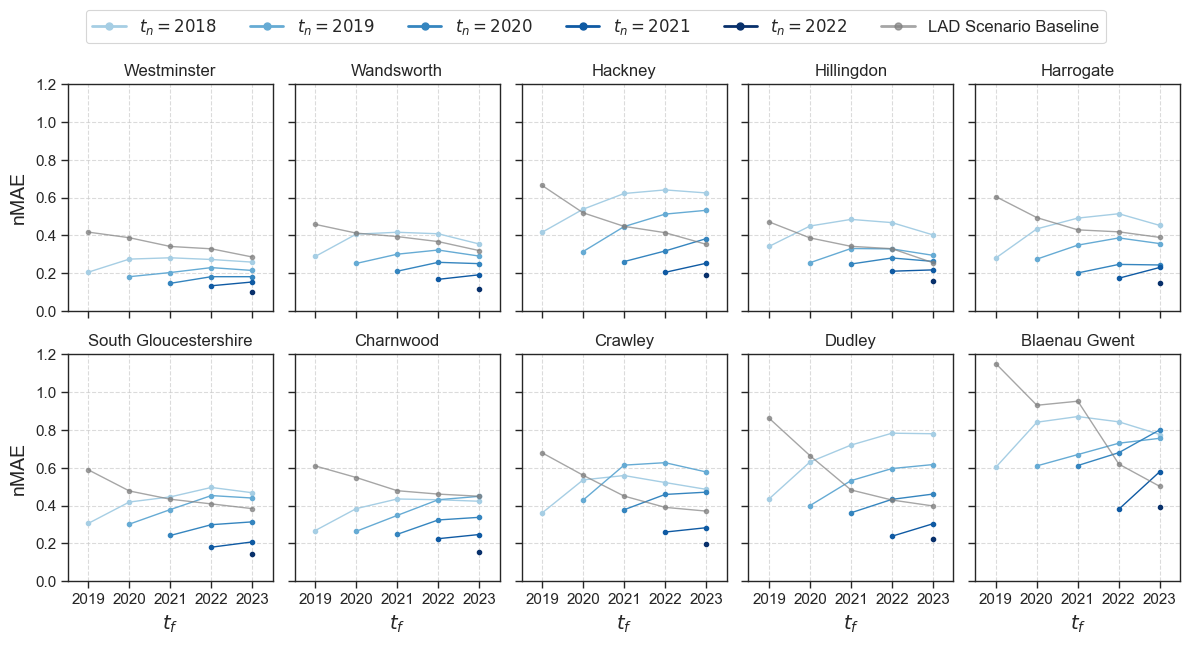

In [165]:
tn_years = list(range(2018, 2023))

cmap = truncate_colormap_discrete(plt.cm.Blues, minval=0.35, maxval=1, n=5)
colors = {t_n: cmap[i] for i, t_n in enumerate(tn_years)}

fig, axes = plt.subplots(figsize=(12, 6), ncols=5, nrows=2, sharex=True, sharey=True)
axes = axes.flatten()

for i, lad in enumerate(lad_array):
    ax = axes[i]

    for t_n in tn_years:
        x_vals = []
        y_vals = []
        for h_f in range(1, 6):
            t_f = t_n + h_f
            if t_f <= 2023:
                try:
                    y = forecast_validator.nmae_dict[h_f].loc[lad, t_n]
                    if pd.notna(y):
                        x_vals.append(t_f)
                        y_vals.append(y)
                except KeyError:
                    continue

        if x_vals:
            ax.plot(x_vals, y_vals, marker='o', label=f'$t_n={t_n}$',
                    color=colors[t_n], alpha=1, ms=3, lw=1)
            
    ax.plot(top_down_estimates_nmae.loc[lad], marker='o', color='grey', alpha=0.7, ms=3, lw=1)

    ax.grid(axis='both', linestyle='--', alpha=0.7)
    ax.set_xlim(2018.5, 2023.5)
    ax.set_xticks(range(2019, 2024))
    ax.set_ylim(bottom=0, top=1.2)
    ax.tick_params(axis='both', labelsize=11)
    ax.set_title(lad, fontsize=12)

    if i % 5 == 0:
        ax.set_ylabel('nMAE', fontsize=14, labelpad=5)

    if i >= 5:
        ax.set_xlabel('$t_f$', fontsize=14, labelpad=5)

# Create legend
handles = []
labels = []
for t_n in tn_years:
    handle, = plt.plot([], [], color=colors[t_n], label=f"$t_n={t_n}$", linewidth=2, alpha=1, marker='o', markersize=5)
    handles.append(handle)
    labels.append(f"$t_n={t_n}$")

# Add baseline to legend
baseline_handle, = plt.plot([], [], color='grey', alpha=0.7, label="LAD Scenario Baseline", linewidth=2, marker='o', markersize=5)
handles.append(baseline_handle)
labels.append("LAD Scenario Baseline")

# Add the shared legend
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=6,
    fontsize=12
)

plt.tight_layout()
plt.savefig('../figures/normalised_mae.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

### ME

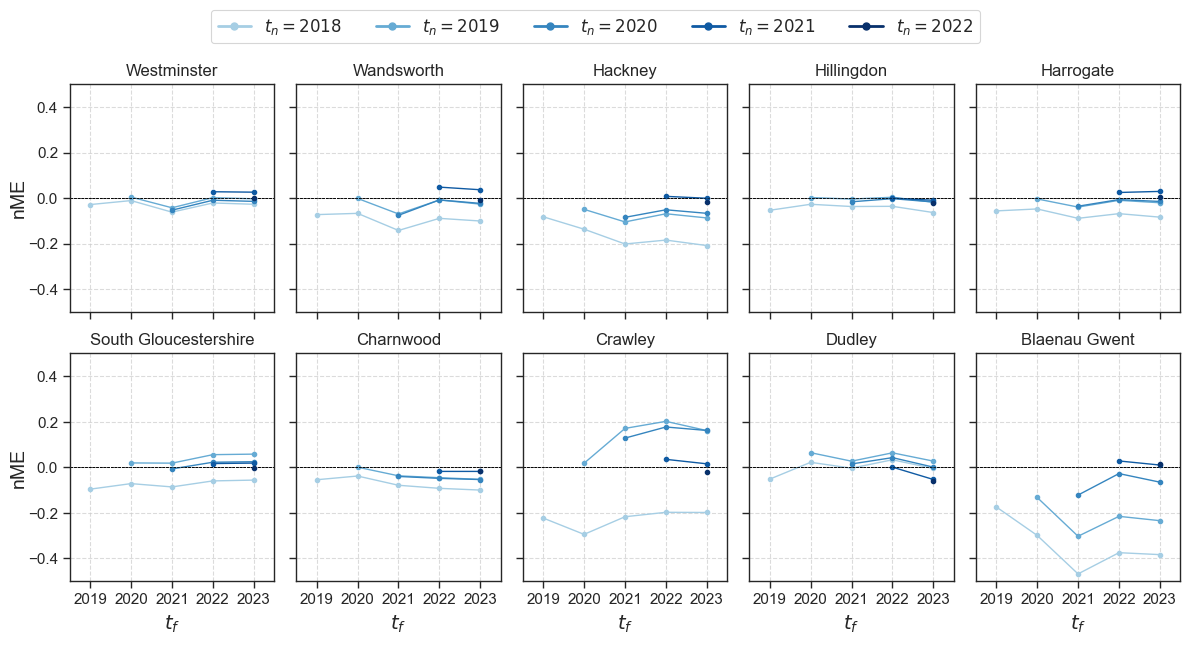

In [166]:
cmap = truncate_colormap_discrete(plt.cm.Blues, minval=0.35, maxval=1, n=5)
colors = {t_n: cmap[i] for i, t_n in enumerate(tn_years)}

fig, axes = plt.subplots(figsize=(12, 6), ncols=5, nrows=2, sharex=True, sharey=True)
axes = axes.flatten()

for i, lad in enumerate(lad_array):
    ax = axes[i]

    for t_n in tn_years:
        x_vals = []
        y_vals = []
        for h_f in range(1, 6):
            t_f = t_n + h_f
            if t_f <= 2023:
                try:
                    y = forecast_validator.nme_dict[h_f].loc[lad, t_n]
                    if pd.notna(y):
                        x_vals.append(t_f)
                        y_vals.append(y)
                except KeyError:
                    continue

        if x_vals:
            ax.axhline(y=0, linestyle='--', color='black', lw=0.5, alpha=0.7)

            ax.plot(x_vals, y_vals, marker='o', label=f'$t_n={t_n}$',
                    color=colors[t_n], alpha=1, ms=3, lw=1)

    ax.grid(axis='both', linestyle='--', alpha=0.7)
    ax.set_xlim(2018.5, 2023.5)
    ax.set_xticks(range(2019, 2024))
    ax.set_ylim(bottom=-0.5, top=0.5)
    ax.tick_params(axis='both', labelsize=11)
    ax.set_title(lad, fontsize=12)

    if i % 5 == 0:
        ax.set_ylabel('nME', fontsize=14, labelpad=0)

    if i >= 5:
        ax.set_xlabel('$t_f$', fontsize=14, labelpad=5)

# Create the legend
handles = []
labels = []
for t_n in tn_years:
    handle, = plt.plot([], [], color=colors[t_n], label=f"$t_n={t_n}$", linewidth=2, alpha=1, marker='o', markersize=5)
    handles.append(handle)
    labels.append(f"$t_n={t_n}$")

# Add the shared legend
fig.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=6,
    fontsize=12
)

plt.tight_layout()
plt.savefig('../figures/normalised_me.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()

### PICP

In [76]:
def plot_picp(observations: pd.Series, forecast_mean: pd.Series, forecast_var: pd.Series, ax=None, color: str='C0'):
    from scipy.stats import norm
    import matplotlib.pyplot as plt
    import numpy as np

    confidence_levels = np.arange(0, 1.01, 0.01)
    observations = observations.values
    predicted_mean = forecast_mean.astype(float).values
    predicted_std = np.sqrt(forecast_var.astype(float).values)

    # Compute empirical coverage
    empirical_coverage = []
    for level in confidence_levels:
        z_score = norm.ppf(0.5 + level / 2)
        lower_bound = predicted_mean - z_score * predicted_std
        upper_bound = predicted_mean + z_score * predicted_std
        empirical_coverage.append(np.mean((observations >= lower_bound) & (observations <= upper_bound)))

    # Handle plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(confidence_levels, empirical_coverage, lw=1, alpha=0.8, color=color)
    ax.plot([0, 1], [0, 1], linestyle="--", color="black")

    ax.set_xlabel("Nominal Coverage Probability", fontsize=11)
    ax.set_ylabel("Empirical Coverage Probability", fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Prediction Interval Calibration")
    ax.grid(True)

    # Only show the plot if a figure was created internally
    if ax is None:
        plt.show()

def plot_picp_array(h_f: int, color_map: object, filename: str):
    # Define the forecast origins (t_n) and evaluation years (t_f)
    tn_years = np.arange(2018, 2023 - h_f + 1)
    n_traces = len(tn_years)

    # Colormap setup
    cmap = truncate_colormap_discrete(color_map, minval=0.3, maxval=1.0, n=n_traces)
    colors = {t_n: cmap[i] for i, t_n in enumerate(tn_years)}

    # Subplot setup
    n_cols = 5
    n_rows = 2
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2 * n_cols, 2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()

    # Plotting loop
    for idx, lad in enumerate(lad_array):
        ax = axes[idx]

        for t_n in tn_years:
            t_f = t_n + h_f

            # Get observed EV market share and transform with probit
            data = lad_lsoa_dict[lad]['ev_ms']
            data = data.loc[:, data.notna().any()]  # drop all-NaN columns
            if t_f not in data.index:
                continue
            observations = data.loc[t_f].map(probit)

            # Get forecast mean and variance for t_n predicting t_f
            try:
                forecast_mean = mean_dict[t_n][lad].loc[t_f]
                forecast_var = var_dict[t_n][lad].loc[t_f]
            except KeyError:
                continue

            # Plot with custom color per t_n
            plot_picp(
                observations=observations,
                forecast_mean=forecast_mean,
                forecast_var=forecast_var,
                ax=ax,
                color=colors[t_n]
            )

        ax.set_title(lad, fontsize=12)
        ax.set_xlabel("", fontsize=12)
        ax.set_ylabel("", fontsize=12)
        if idx % n_cols == 0:
            ax.set_ylabel("Observed\nFrequency", fontsize=12, labelpad=5)
        if idx >= n_cols * (n_rows - 1):
            ax.set_xlabel("Prediction Interval", fontsize=12, labelpad=5)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Remove axes
    for idx in range(len(lad_array), len(axes)):
        fig.delaxes(axes[idx])

    # Add shared legend
    handles = []
    labels = []
    for t_n in tn_years:
        handle, = plt.plot([], [], color=colors[t_n], label=f"$t_n={t_n}$\n$t_f={t_n + h_f}$ ", linewidth=3, alpha=0.8)
        handles.append(handle)
        labels.append(f"$t_n={t_n}$")

    # Add "perfect calibration" to legend
    baseline_handle, = plt.plot([], [], color='black', label="Perfect Calibration", linewidth=2, alpha=1, linestyle='--')
    handles.append(baseline_handle)
    labels.append("Perfect Calibration")
        
    fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=n_traces+1,
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(f'{filename}', bbox_inches="tight", pad_inches=0.2, dpi=300)
    plt.show()

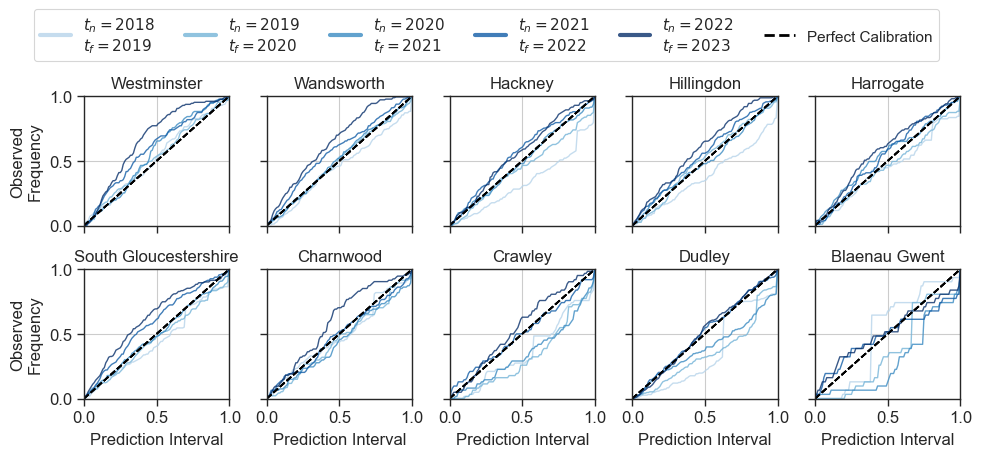

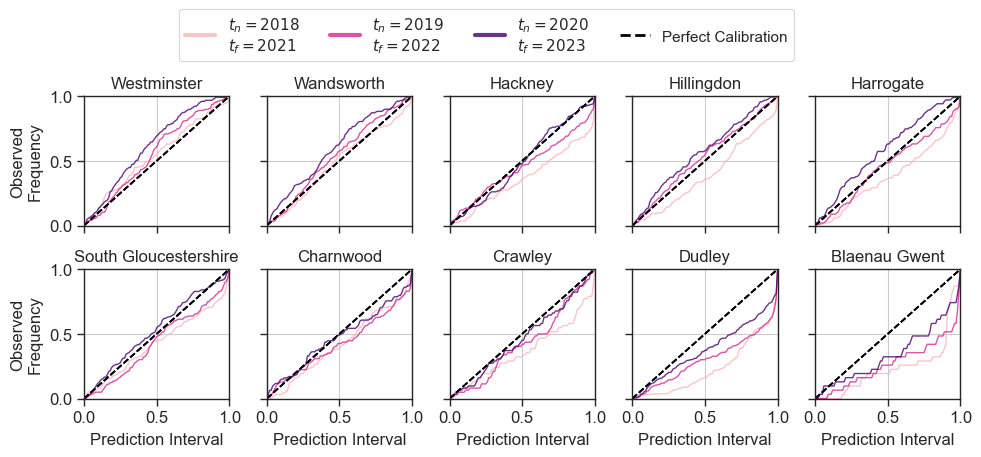

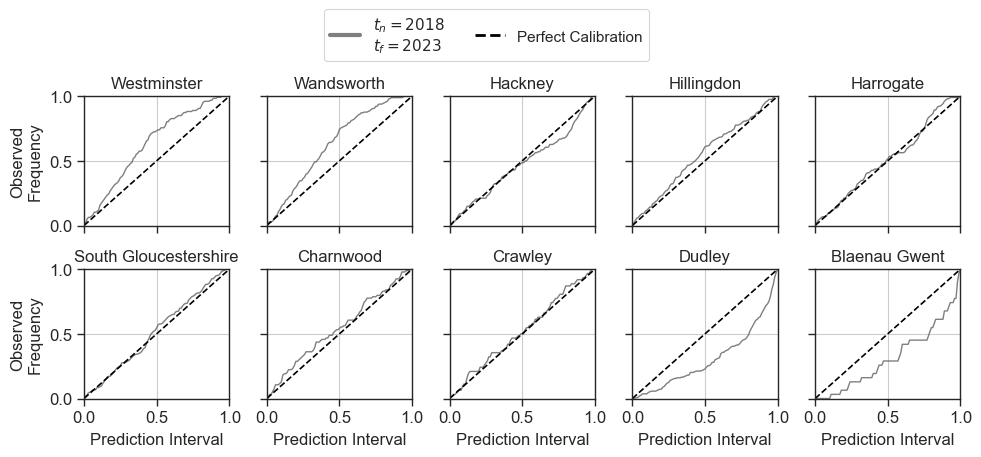

In [167]:
plot_picp_array(h_f=1, color_map=plt.cm.Blues, filename='../figures/picp_array_1y')
plot_picp_array(h_f=3, color_map=plt.cm.RdPu, filename='../figures/picp_array_3y')
plot_picp_array(h_f=5, color_map=plt.cm.Greys_r, filename='../figures/picp_array_5y')

# Impact of the Number of Non-Zero Data Points on nMAE

In [168]:
mean_lsoa_non_zero_data_count = pd.DataFrame(index=lad_array, columns=range(2018, 2023))
for t_n in range(2018, 2023):
    for lad in lad_array:
        data = lad_lsoa_dict[lad]['ev_ms']
        data = data.loc[:, data.notna().any()]
        mean_lsoa_non_zero_data_count.loc[lad, t_n] = (data.loc[: t_n] > 0).sum().mean()

mean_lsoa_non_zero_data_count

,2018,2019,2020,2021,2022
Westminster,4.866142,5.866142,6.866142,7.866142,8.866142
Wandsworth,3.145251,4.134078,5.128492,6.128492,7.128492
Hackney,1.880282,2.732394,3.676056,4.669014,5.669014
Hillingdon,2.590062,3.57764,4.57764,5.57764,6.57764
Harrogate,2.291262,3.165049,4.145631,5.135922,6.126214
South Gloucestershire,2.546012,3.398773,4.343558,5.331288,6.325153
Charnwood,2.5,3.329787,4.212766,5.180851,6.159574
Crawley,1.532258,2.370968,3.274194,4.258065,5.258065
Dudley,1.53886,2.233161,3.051813,4.025907,5.025907
Blaenau Gwent,0.612903,1.096774,1.741935,2.516129,3.451613


In [79]:
def fit_gp(mean_lsoa_non_zero_data_count: pd.DataFrame, norm_mae_dict_full: dict, h_f: int, t_n_array, X_pred: np.ndarray):
    x_data = []
    y_data = []

    for t_n in t_n_array:
        x_vals = mean_lsoa_non_zero_data_count[t_n]
        y_vals = norm_mae_dict_full[h_f][t_n]
        x_data.extend(x_vals)
        y_data.extend(y_vals)

    X = np.array(x_data).reshape(-1, 1).astype(np.float64)
    Y = np.array(y_data).reshape(-1, 1).astype(np.float64)
    logY = np.log(Y)

    # Define kernel and model
    kernel = gpflow.kernels.SquaredExponential(lengthscales=10.0, variance=5.0)
    model = gpflow.models.GPR(data=(X, logY), kernel=kernel, mean_function=None)

    # Train (optimize the marginal likelihood)
    opt = gpflow.optimizers.Scipy()
    opt_logs = opt.minimize(model.training_loss, model.trainable_variables)

    # Predict
    mean, var = model.predict_y(X_pred)
    mean = mean.numpy()
    var = var.numpy()
    return mean, var

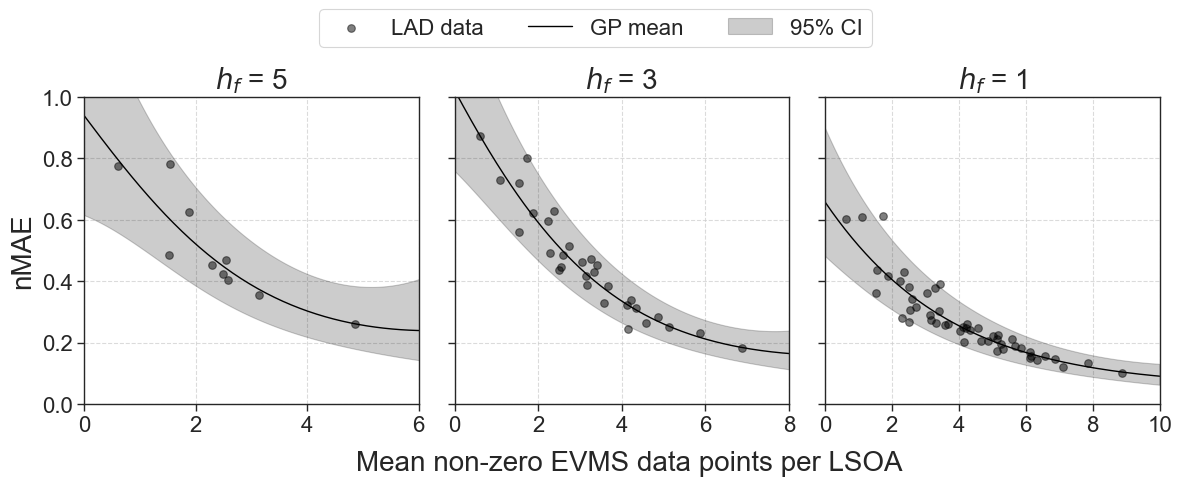

In [169]:
X_pred = np.linspace(0, 10, 200).reshape(-1, 1)

fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(12, 4), sharey=True)

for i, h_f in enumerate([5, 3, 1]):
    ax = axes[i]

    t_n_array = np.arange(2018, 2023-h_f+1)
    mean, var = fit_gp(mean_lsoa_non_zero_data_count, forecast_validator.nmae_dict, h_f, t_n_array, X_pred)

    # Original scatter points
    for t_n in t_n_array:
        ax.scatter(mean_lsoa_non_zero_data_count[t_n], forecast_validator.nmae_dict[h_f][t_n], color='black', s=30, alpha=0.5)
    
    ax.scatter([], [], color='black', s=30, label='LAD data', alpha=0.5)

    # GP mean and 95% confidence interval
    ax.plot(X_pred, np.exp(mean), 'k-', lw=1, label='GP mean')
    ax.fill_between(X_pred.ravel(),
                    (np.exp(mean - 2*np.sqrt(var))).ravel(),
                    (np.exp(mean + 2*np.sqrt(var))).ravel(),
                    color='black', alpha=0.2, label='95% CI')

    ax.grid(axis='both', linestyle='--', alpha=0.7)
    if i==0:
        ax.set_ylabel('nMAE', fontsize=20)
    ax.set_xlabel('')
    ax.set_title(f'$h_f$ = {h_f}', fontsize=20)
    ax.set_xlim(left=0, right=round(max(mean_lsoa_non_zero_data_count[t_n]))+1)
    ax.set_ylim(bottom=0, top=1)
    ax.tick_params(labelsize=16)
fig.text(x=0.3, y=-0.05, s='Mean non-zero EVMS data points per LSOA', fontsize=20)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=16, bbox_to_anchor=(0.5, 1.13))

plt.tight_layout()
plt.savefig('../figures/non_zero_vs_norm_mae.png', bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()